In [19]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("TATAMOTORS.csv")

# Keep important features (simplified from 11 → 5 for better learning)
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [10]:
scaler = MinMaxScaler()
data = scaler.fit_transform(df)

In [11]:
def create_sequences(data, seq_length=5):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][3])  # predict Close
    return np.array(X), np.array(y)

X, y = create_sequences(data)

In [12]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [13]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=5, hidden_size=50, batch_first=True)
        self.fc = nn.Linear(50, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [14]:
for epoch in range(20):
    model.train()
    output = model(X_train)
    loss = criterion(output.squeeze(), y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.13572293519973755
Epoch 2, Loss: 0.12508897483348846
Epoch 3, Loss: 0.11507229506969452
Epoch 4, Loss: 0.10565167665481567
Epoch 5, Loss: 0.09680334478616714
Epoch 6, Loss: 0.08850063383579254
Epoch 7, Loss: 0.08071628957986832
Epoch 8, Loss: 0.07342556864023209
Epoch 9, Loss: 0.0666079968214035
Epoch 10, Loss: 0.06024811044335365
Epoch 11, Loss: 0.054335933178663254
Epoch 12, Loss: 0.04886713996529579
Epoch 13, Loss: 0.04384290426969528
Epoch 14, Loss: 0.039269428700208664
Epoch 15, Loss: 0.035157229751348495
Epoch 16, Loss: 0.03152003511786461
Epoch 17, Loss: 0.028373057022690773
Epoch 18, Loss: 0.025730477645993233
Epoch 19, Loss: 0.023601794615387917
Epoch 20, Loss: 0.02198689989745617


In [15]:
model.eval()
pred = model(X_test).detach().numpy()
y_test_np = y_test.numpy()

In [16]:
mse = mean_squared_error(y_test_np, pred)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test_np - pred))

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 0.017763033509254456
RMSE: 0.1332780308575065
MAE: 0.1316492


In [17]:
# Convert predictions & actual values into direction (UP/DOWN)

y_true = y_test_np
y_pred = pred.flatten()

# Direction: 1 = UP, 0 = DOWN
y_true_dir = (y_true[1:] > y_true[:-1]).astype(int)
y_pred_dir = (y_pred[1:] > y_pred[:-1]).astype(int)

# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true_dir, y_pred_dir)

print("Directional Accuracy:", accuracy * 100)

Directional Accuracy: 51.03773584905661


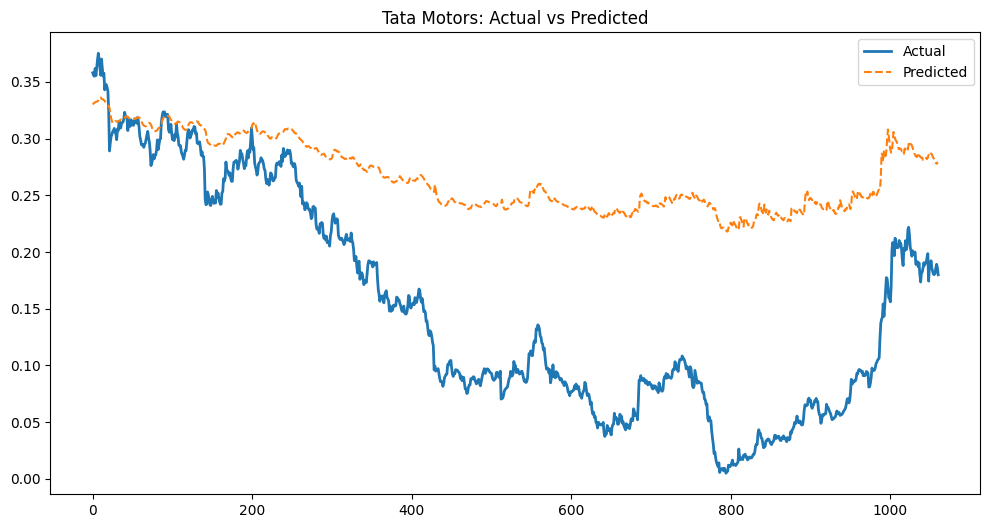

In [20]:
plt.figure(figsize=(12,6))

# Shift predictions to align with test data
pred_plot = np.empty_like(y_test_np)
pred_plot[:] = np.nan
pred_plot[:] = pred.flatten()

plt.plot(y_test_np, label="Actual", linewidth=2)
plt.plot(pred_plot, label="Predicted", linestyle="dashed")

plt.title("Tata Motors: Actual vs Predicted")
plt.legend()

plt.show()

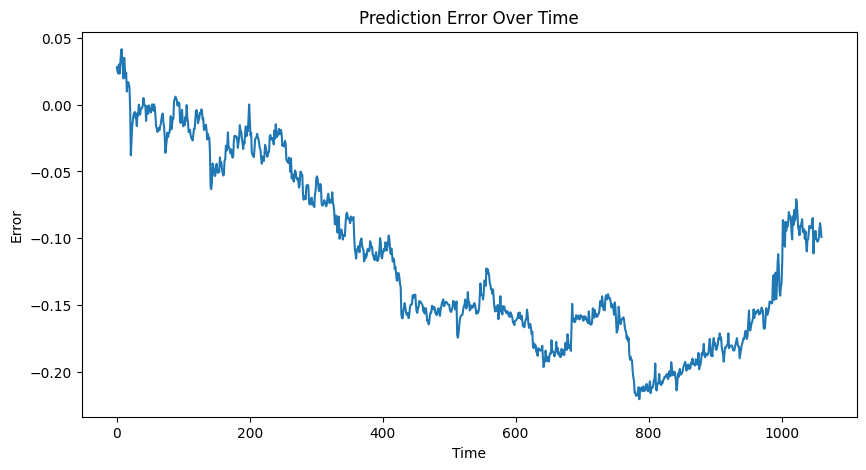

In [21]:
error = y_test_np - pred.flatten()

plt.figure(figsize=(10,5))
plt.plot(error)

plt.title("Prediction Error Over Time")
plt.xlabel("Time")
plt.ylabel("Error")

plt.show()